In [1]:
# ==========================================
# CELL 1: IMPORT LIBRARIES & SETUP
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dùng font mặc định siêu an toàn của hệ thống
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False 

# Cấu hình thẩm mỹ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set1")

print("CELL 1 COMPLETED: Libraries loaded successfully!")

CELL 1 COMPLETED: Libraries loaded successfully!


In [2]:
# ==========================================
# CELL 2: LOAD DATA & TIỀN XỬ LÝ
# ==========================================

# 1. Định nghĩa đường dẫn (Đảm bảo file nằm cùng thư mục hoặc sửa lại đường dẫn Kaggle của bạn)
PATH_SUMMARY = "/kaggle/input/datasets/maomaoxiaobng/tmptmp/benchmark_summary.csv"
PATH_PRUNING = "/kaggle/input/datasets/maomaoxiaobng/tmptmp/pruning_details.csv"
PATH_HEURISTIC = "/kaggle/input/datasets/maomaoxiaobng/tmptmp/eval_heuristic_log.csv"

# 2. Load dữ liệu
try:
    df_summary = pd.read_csv(PATH_SUMMARY)
    df_pruning = pd.read_csv(PATH_PRUNING)
    df_heuristic = pd.read_csv(PATH_HEURISTIC)
    print("Successfully downloaded 3 log files!")
except Exception as e:
    print(f"Lỗi tải dữ liệu: {e}")

# 3. Tiền xử lý: Tính toán Tỷ lệ cắt nhánh (Pruning Efficiency) cho EDA 3
# Lọc lấy số Node của Minimax làm gốc (Chân lý 100%)
df_mm = df_summary[df_summary['Algorithm'] == 'Minimax'][['State_Name', 'Depth_Limit', 'Total_Visited_Nodes']]
df_mm = df_mm.rename(columns={'Total_Visited_Nodes': 'Nodes_MM'})

# Ghép với các thuật toán còn lại (Alpha-Beta, v.v.)
df_other = df_summary[df_summary['Algorithm'] != 'Minimax'].copy()
df_compare = pd.merge(df_other, df_mm, on=['State_Name', 'Depth_Limit'])

# Công thức: (Node_MM - Node_Thuật_Toán_Khác) / Node_MM * 100
df_compare['Pruning_Efficiency'] = ((df_compare['Nodes_MM'] - df_compare['Total_Visited_Nodes']) / df_compare['Nodes_MM']) * 100

print("CELL 2 COMPLETED: The calculations for the derived data fields have been completed!")

Successfully downloaded 3 log files!
CELL 2 COMPLETED: The calculations for the derived data fields have been completed!


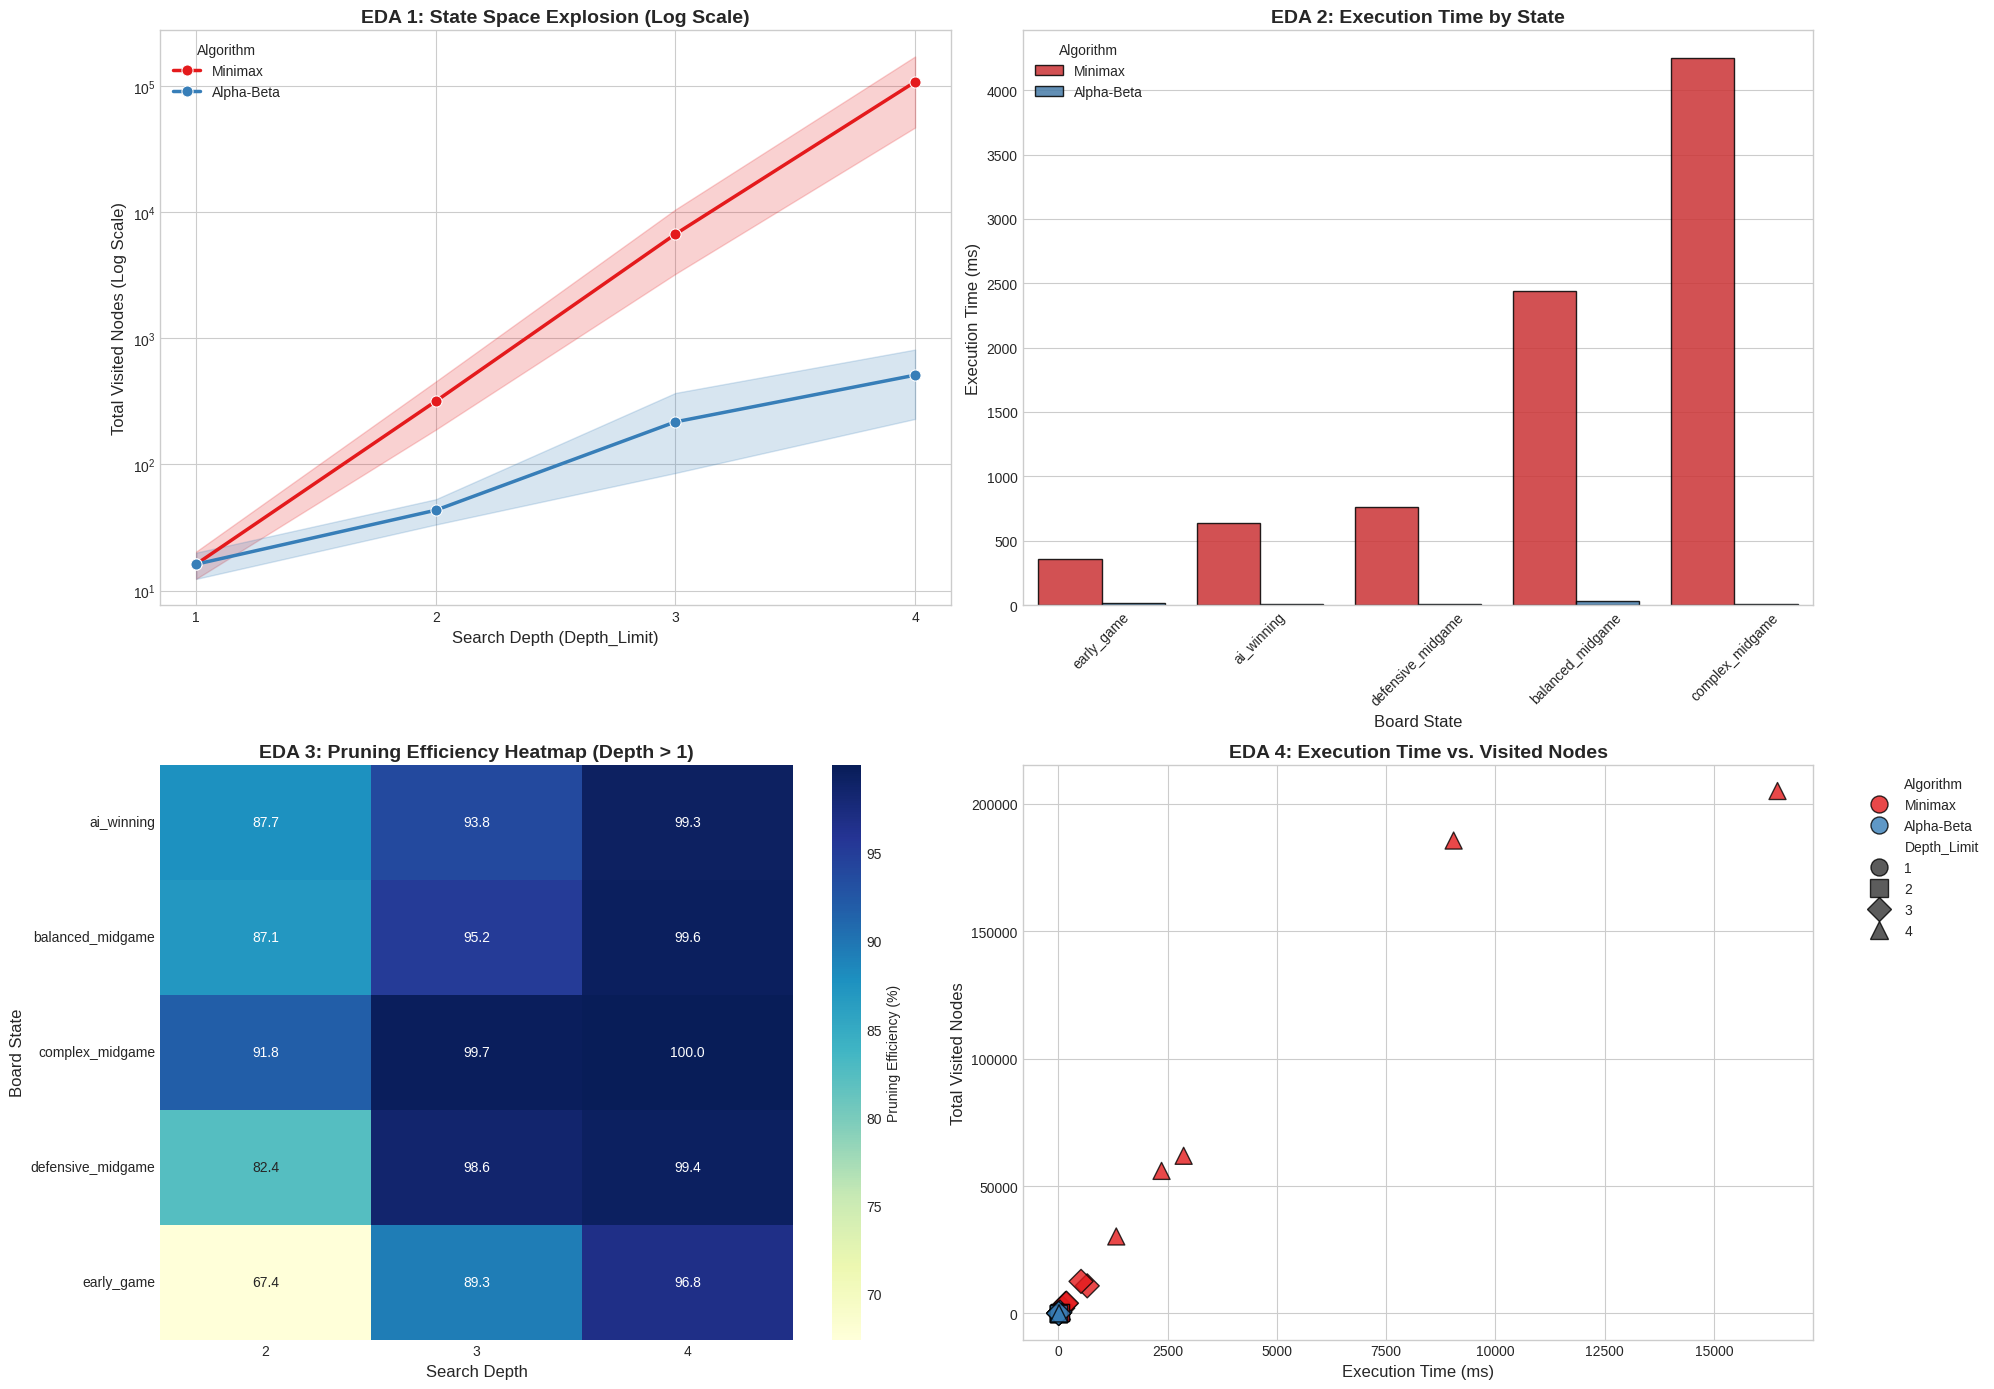

CELL 3 COMPLETED: TIER 1 chart saved as TIER1_Core_Performance_EN.png


In [3]:
# ==========================================
# CELL 3: TIER 1 - CORE PERFORMANCE
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(20, 14))

# ------------------------------------------------------------------------------
# EDA 1: STATE SPACE EXPLOSION (NODES VS DEPTH)
# ------------------------------------------------------------------------------
sns.lineplot(data=df_summary, x='Depth_Limit', y='Total_Visited_Nodes', 
             hue='Algorithm', marker='o', linewidth=2.5, markersize=8, ax=axs[0, 0])
axs[0, 0].set_yscale('log')
axs[0, 0].set_xticks(sorted(df_summary['Depth_Limit'].unique())) 

axs[0, 0].set_title('EDA 1: State Space Explosion (Log Scale)', fontsize=14, fontweight='bold')
axs[0, 0].set_xlabel('Search Depth (Depth_Limit)', fontsize=12)
axs[0, 0].set_ylabel('Total Visited Nodes (Log Scale)', fontsize=12)

# ------------------------------------------------------------------------------
# EDA 2: EXECUTION TIME 
# ------------------------------------------------------------------------------
sns.barplot(data=df_summary, x='State_Name', y='Execution_Time_ms', 
            hue='Algorithm', errorbar=None, ax=axs[0, 1], edgecolor='black', alpha=0.85)
axs[0, 1].set_title('EDA 2: Execution Time by State', fontsize=14, fontweight='bold')
axs[0, 1].set_xlabel('Board State', fontsize=12)
axs[0, 1].set_ylabel('Execution Time (ms)', fontsize=12)
axs[0, 1].tick_params(axis='x', rotation=45)

# ------------------------------------------------------------------------------
# EDA 3: PRUNING EFFICIENCY HEATMAP 
# ------------------------------------------------------------------------------
# Lọc bỏ Depth 1
df_compare_eda3 = df_compare[df_compare['Depth_Limit'] > 1]
pivot_pruning = df_compare_eda3.pivot_table(index='State_Name', columns='Depth_Limit', 
                                            values='Pruning_Efficiency', aggfunc='mean')

sns.heatmap(pivot_pruning, annot=True, fmt=".1f", cmap="YlGnBu", 
            cbar_kws={'label': 'Pruning Efficiency (%)'}, ax=axs[1, 0])
axs[1, 0].set_title('EDA 3: Pruning Efficiency Heatmap (Depth > 1)', fontsize=14, fontweight='bold')
axs[1, 0].set_xlabel('Search Depth', fontsize=12)
axs[1, 0].set_ylabel('Board State', fontsize=12)

# ------------------------------------------------------------------------------
# EDA 4: CORRELATION (TIME VS NODES)
# ------------------------------------------------------------------------------
unique_depths = sorted(df_summary['Depth_Limit'].unique())
available_markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'X', 'h', 'H', '+', 'x', '|']
dynamic_markers = available_markers[:len(unique_depths)]

sns.scatterplot(data=df_summary, x='Execution_Time_ms', y='Total_Visited_Nodes', 
                hue='Algorithm', style='Depth_Limit', markers=dynamic_markers, 
                s=150, alpha=0.8, edgecolor='black', ax=axs[1, 1])
axs[1, 1].set_title('EDA 4: Execution Time vs. Visited Nodes', fontsize=14, fontweight='bold')
axs[1, 1].set_xlabel('Execution Time (ms)', fontsize=12)
axs[1, 1].set_ylabel('Total Visited Nodes', fontsize=12)
axs[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# ------------------------------------------------------------------------------
# XUẤT ẢNH VÀ HIỂN THỊ
# ------------------------------------------------------------------------------
plt.tight_layout()
plt.savefig('TIER1_Core_Performance_EN.png', dpi=300, bbox_inches='tight')
plt.show()

print("CELL 3 COMPLETED: TIER 1 chart saved as TIER1_Core_Performance_EN.png")

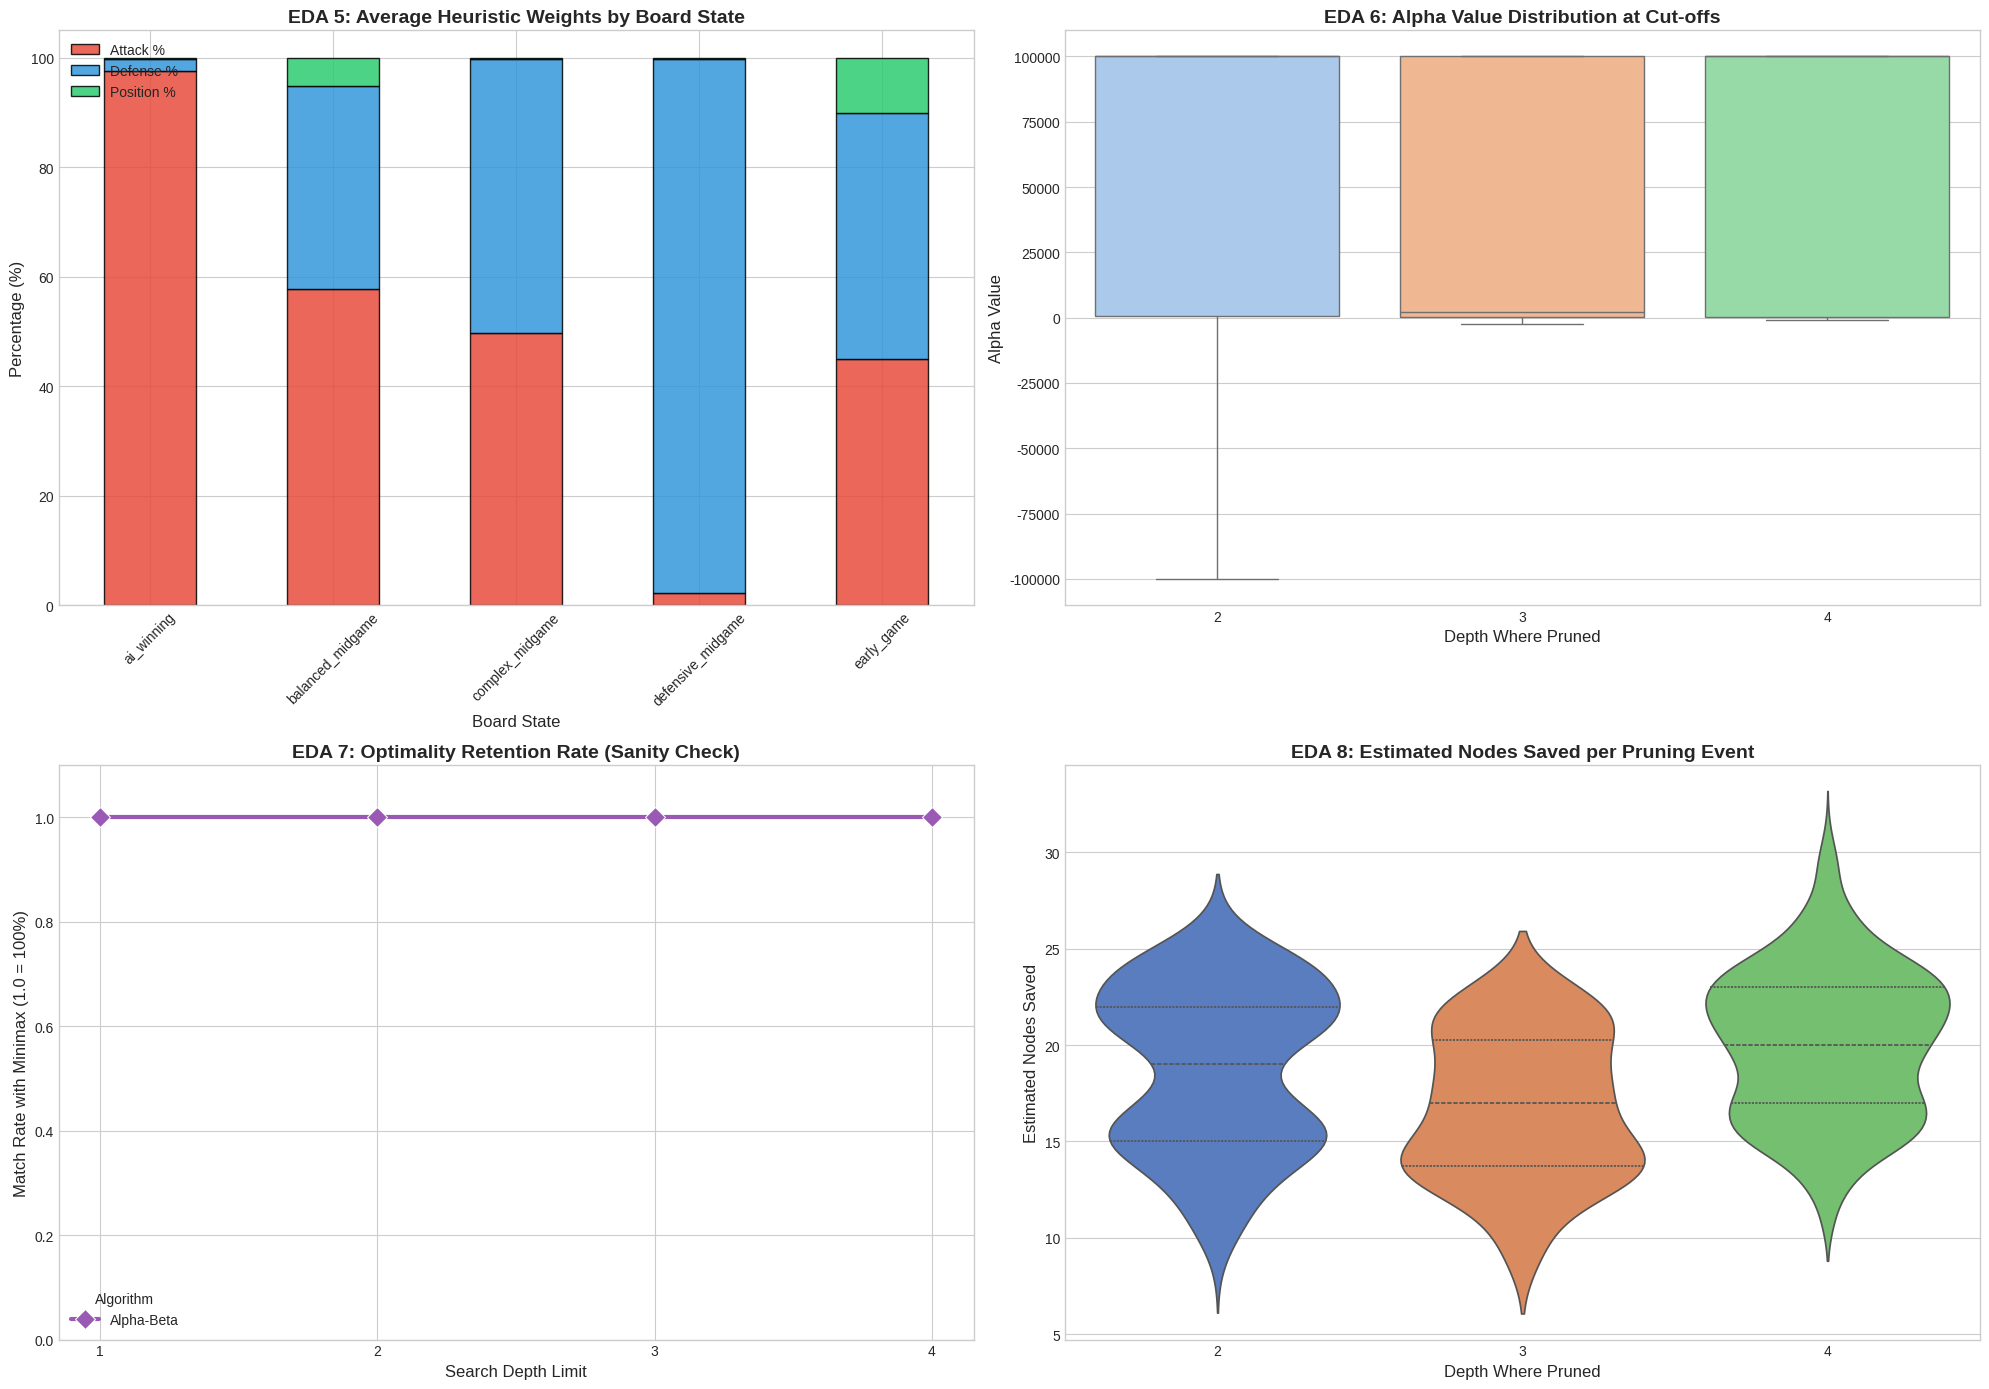

CELL 4 COMPLETED: TIER 2 chart saved as TIER2_AI_Diagnostics_EN.png


In [4]:
# ==========================================
# CELL 4: TIER 2 - DIAGNOSTICS & AI BEHAVIOR
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

fig, axs = plt.subplots(2, 2, figsize=(20, 14))

# ------------------------------------------------------------------------------
# EDA 5: HEURISTIC COMPONENT BREAKDOWN (100% STACKED BAR)
# ------------------------------------------------------------------------------
# 1. Khai báo biến df_heu_state (Dòng này hôm trước bạn bị thiếu)
df_heu_state = pd.merge(df_heuristic, df_summary[['Test_ID', 'State_Name']], on='Test_ID')

# 2. Tính trung bình điểm
heu_avg = df_heu_state.groupby('State_Name')[['Score_Attack', 'Score_Defense', 'Position_Weight']].mean()

# 3. Chuẩn hóa về tỷ lệ 100%
heu_avg_pct = heu_avg.div(heu_avg.sum(axis=1), axis=0) * 100

# 4. Vẽ biểu đồ
heu_avg_pct.plot(kind='bar', stacked=True, ax=axs[0, 0], 
                 color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black', alpha=0.85)

axs[0, 0].set_title('EDA 5: Average Heuristic Weights by Board State', fontsize=14, fontweight='bold')
axs[0, 0].set_xlabel('Board State', fontsize=12)
axs[0, 0].set_ylabel('Percentage (%)', fontsize=12)
axs[0, 0].tick_params(axis='x', rotation=45)
axs[0, 0].legend(['Attack %', 'Defense %', 'Position %'], loc='upper left')

# ------------------------------------------------------------------------------
# EDA 6: ALPHA VALUE DISTRIBUTION AT PRUNING POINTS (BOXPLOT)
# ------------------------------------------------------------------------------
sns.boxplot(data=df_pruning, x='Depth_Where_Pruned', y='Alpha_Value', 
            hue='Depth_Where_Pruned', ax=axs[0, 1], palette="pastel", legend=False)

axs[0, 1].set_title('EDA 6: Alpha Value Distribution at Cut-offs', fontsize=14, fontweight='bold')
axs[0, 1].set_xlabel('Depth Where Pruned', fontsize=12)
axs[0, 1].set_ylabel('Alpha Value', fontsize=12)

# ------------------------------------------------------------------------------
# EDA 7: OPTIMALITY RETENTION RATE (SANITY CHECK)
# ------------------------------------------------------------------------------
df_mm_truth = df_summary[df_summary['Algorithm'] == 'Minimax'][['State_Name', 'Depth_Limit', 'Best_Move_X', 'Best_Move_Y']]
df_ab_test = df_summary[df_summary['Algorithm'] != 'Minimax'].copy()

df_opt = pd.merge(df_ab_test, df_mm_truth, on=['State_Name', 'Depth_Limit'], suffixes=('', '_Truth'))
df_opt['Is_Optimal'] = ((df_opt['Best_Move_X'] == df_opt['Best_Move_X_Truth']) & 
                        (df_opt['Best_Move_Y'] == df_opt['Best_Move_Y_Truth'])).astype(float)

opt_rate = df_opt.groupby(['Algorithm', 'Depth_Limit'])['Is_Optimal'].mean().reset_index()

sns.lineplot(data=opt_rate, x='Depth_Limit', y='Is_Optimal', hue='Algorithm',
             marker='D', markersize=10, linewidth=3, ax=axs[1, 0], palette=['#9b59b6'])

axs[1, 0].set_title('EDA 7: Optimality Retention Rate (Sanity Check)', fontsize=14, fontweight='bold')
axs[1, 0].set_xlabel('Search Depth Limit', fontsize=12)
axs[1, 0].set_ylabel('Match Rate with Minimax (1.0 = 100%)', fontsize=12)
axs[1, 0].set_ylim(0, 1.1)
axs[1, 0].set_xticks(sorted(df_summary['Depth_Limit'].unique()))

# ------------------------------------------------------------------------------
# EDA 8: PRUNED NODES VOLUME VS DEPTH (VIOLIN PLOT)
# ------------------------------------------------------------------------------
sns.violinplot(data=df_pruning, x='Depth_Where_Pruned', y='Nodes_Pruned_Estimate', 
               hue='Depth_Where_Pruned', ax=axs[1, 1], palette="muted", inner="quartile", legend=False)

axs[1, 1].set_title('EDA 8: Estimated Nodes Saved per Pruning Event', fontsize=14, fontweight='bold')
axs[1, 1].set_xlabel('Depth Where Pruned', fontsize=12)
axs[1, 1].set_ylabel('Estimated Nodes Saved', fontsize=12)

# ------------------------------------------------------------------------------
# XUẤT ẢNH VÀ HIỂN THỊ
# ------------------------------------------------------------------------------
plt.tight_layout()
plt.savefig('TIER2_AI_Diagnostics_EN.png', dpi=300, bbox_inches='tight')
plt.show()

print("CELL 4 COMPLETED: TIER 2 chart saved as TIER2_AI_Diagnostics_EN.png")

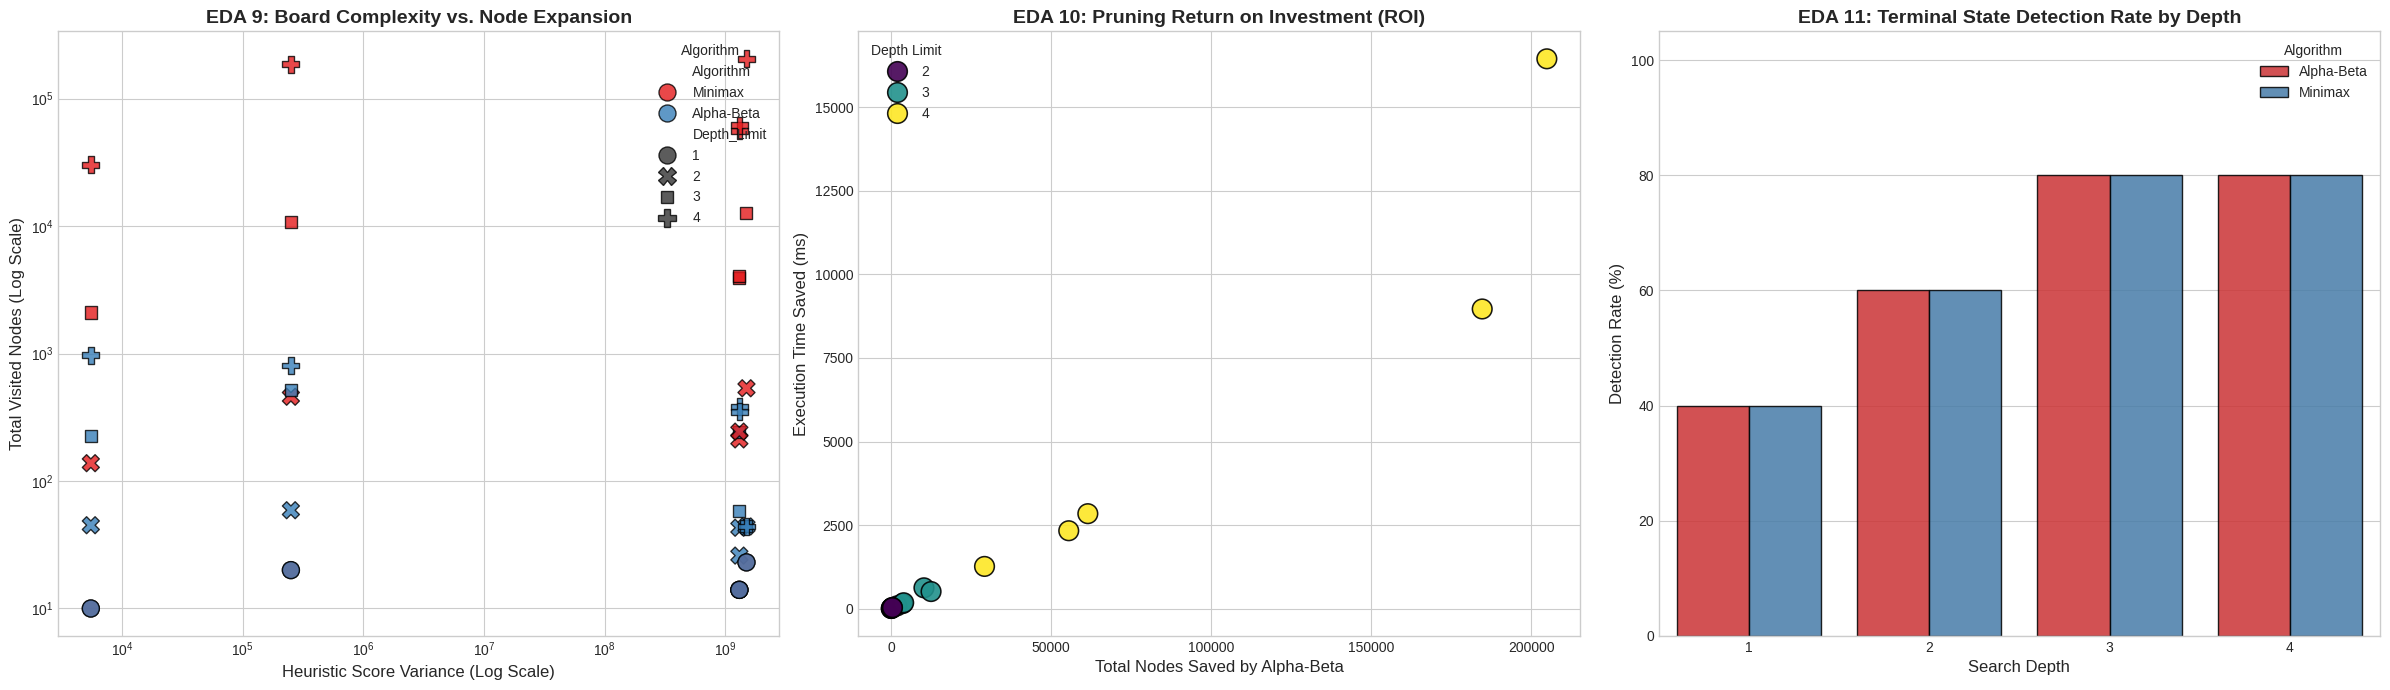

 CELL 5 COMPLETED: TIER 3 chart saved as TIER3_Advanced_Insights_EN.png


In [5]:
# ==========================================
# CELL 5: TIER 3 - ADVANCED SYSTEM INSIGHTS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(24, 7))

# ------------------------------------------------------------------------------
# EDA 9: BOARD COMPLEXITY VS NODE EXPANSION (SCATTER PLOT)
# ------------------------------------------------------------------------------
# Calculate the Variance of heuristic scores for each move to measure "Uncertainty"
heu_var = df_heuristic.groupby('Test_ID')['Final_Heuristic_Score'].var().reset_index()
heu_var = heu_var.fillna(0) # Handle states with only 1 evaluated move
heu_var.rename(columns={'Final_Heuristic_Score': 'Heuristic_Variance'}, inplace=True)
df_var = pd.merge(df_summary, heu_var, on='Test_ID')

# Add +1 to prevent log(0) errors on the X-axis
df_var['Heuristic_Variance'] = df_var['Heuristic_Variance'] + 1 

sns.scatterplot(data=df_var, x='Heuristic_Variance', y='Total_Visited_Nodes', 
                hue='Algorithm', style='Depth_Limit', s=150, ax=axs[0], alpha=0.8, edgecolor='black')

axs[0].set_title('EDA 9: Board Complexity vs. Node Expansion', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Heuristic Score Variance (Log Scale)', fontsize=12)
axs[0].set_ylabel('Total Visited Nodes (Log Scale)', fontsize=12)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend(title='Algorithm', loc='upper right')

# ------------------------------------------------------------------------------
# EDA 10: PRUNING RETURN ON INVESTMENT (ROI)
# ------------------------------------------------------------------------------
# Calculate exact Time and Nodes saved by comparing Minimax with Alpha-Beta
df_mm = df_summary[df_summary['Algorithm'] == 'Minimax'][['State_Name', 'Depth_Limit', 'Total_Visited_Nodes', 'Execution_Time_ms']]
df_ab = df_summary[df_summary['Algorithm'] == 'Alpha-Beta'][['State_Name', 'Depth_Limit', 'Total_Visited_Nodes', 'Execution_Time_ms']]

df_roi = pd.merge(df_mm, df_ab, on=['State_Name', 'Depth_Limit'], suffixes=('_MM', '_AB'))
df_roi['Nodes_Saved'] = df_roi['Total_Visited_Nodes_MM'] - df_roi['Total_Visited_Nodes_AB']
df_roi['Time_Saved_ms'] = df_roi['Execution_Time_ms_MM'] - df_roi['Execution_Time_ms_AB']

# Prevent plotting 0 Nodes Saved (happens at Depth 1)
df_roi_filtered = df_roi[df_roi['Nodes_Saved'] > 0]

sns.scatterplot(data=df_roi_filtered, x='Nodes_Saved', y='Time_Saved_ms', hue='Depth_Limit', 
                palette='viridis', s=200, ax=axs[1], edgecolor='black', alpha=0.9)

axs[1].set_title('EDA 10: Pruning Return on Investment (ROI)', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Total Nodes Saved by Alpha-Beta', fontsize=12)
axs[1].set_ylabel('Execution Time Saved (ms)', fontsize=12)
axs[1].legend(title='Depth Limit')

# ------------------------------------------------------------------------------
# EDA 11: FORCED WIN/LOSS DETECTION RATE
# ------------------------------------------------------------------------------
# Calculate the percentage of finding a terminal state at each depth
win_detect = df_summary.groupby(['Depth_Limit', 'Algorithm'])['Winning_Status_Found'].mean().reset_index()
win_detect['Winning_Status_Found'] *= 100 # Convert to percentage

sns.barplot(data=win_detect, x='Depth_Limit', y='Winning_Status_Found', 
            hue='Algorithm', ax=axs[2], edgecolor='black', alpha=0.85)

axs[2].set_title('EDA 11: Terminal State Detection Rate by Depth', fontsize=14, fontweight='bold')
axs[2].set_xlabel('Search Depth', fontsize=12)
axs[2].set_ylabel('Detection Rate (%)', fontsize=12)
axs[2].set_ylim(0, 105)

# ------------------------------------------------------------------------------
# XUẤT ẢNH VÀ HIỂN THỊ
# ------------------------------------------------------------------------------
plt.tight_layout()
plt.savefig('TIER3_Advanced_Insights_EN.png', dpi=300, bbox_inches='tight')
plt.show()

print(" CELL 5 COMPLETED: TIER 3 chart saved as TIER3_Advanced_Insights_EN.png")

Tải thành công move_matching.csv!


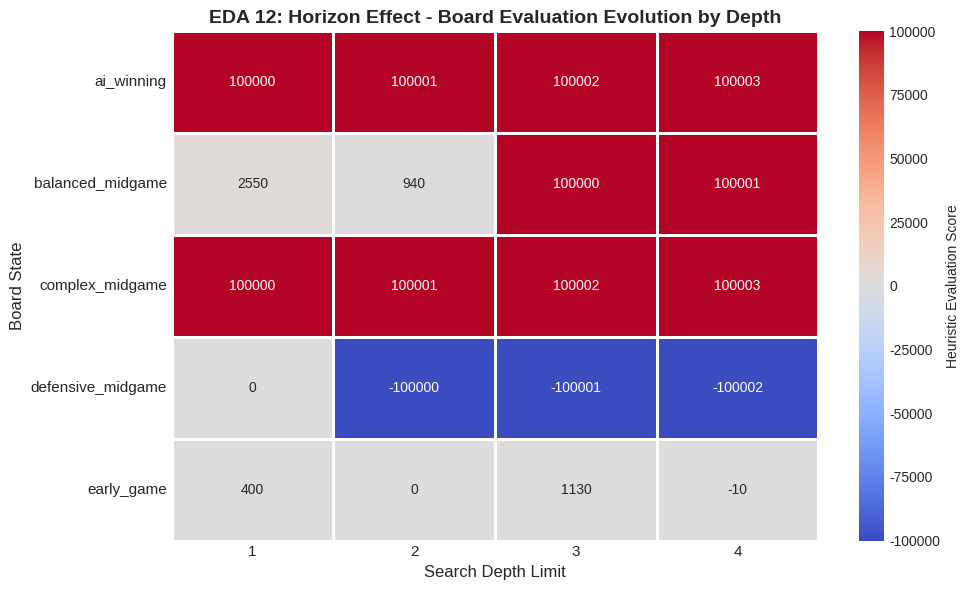

CELL 6 COMPLETED: Saved EDA12_Eval_Evolution_EN.png


In [6]:
# ==========================================
# CELL 6: KIỂM CHỨNG BẰNG MOVE MATCHING (EDA 12)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup font và style tiếng Anh an toàn
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

# Load dữ liệu move_matching
try:
    df_match = pd.read_csv('/kaggle/input/datasets/maomaoxiaobng/tmptmp/move_matching.csv')
    print("Tải thành công move_matching.csv!")
except Exception as e:
    print(f"Lỗi tải dữ liệu: {e}")

# Chuyển đổi dữ liệu sang dạng Pivot Table để vẽ Heatmap
# Ta dùng Minimax_Eval_Score làm đại diện vì điểm Minimax và Alpha-Beta khớp nhau 100%
pivot_eval = df_match.pivot(index='State_Name', columns='Depth_Limit', values='Minimax_Eval_Score')

# Khởi tạo biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ Heatmap với thang màu Coolwarm (Tâm = 0)
sns.heatmap(pivot_eval, annot=True, fmt=".0f", cmap="coolwarm", center=0, 
            cbar_kws={'label': 'Heuristic Evaluation Score'}, 
            linewidths=1, linecolor='white')

# Gắn nhãn
plt.title('EDA 12: Horizon Effect - Board Evaluation Evolution by Depth', fontsize=14, fontweight='bold')
plt.xlabel('Search Depth Limit', fontsize=12)
plt.ylabel('Board State', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

# Xuất file và hiển thị
plt.tight_layout()
plt.savefig('EDA12_Eval_Evolution_EN.png', dpi=300, bbox_inches='tight')
plt.show()

print("CELL 6 COMPLETED: Saved EDA12_Eval_Evolution_EN.png")

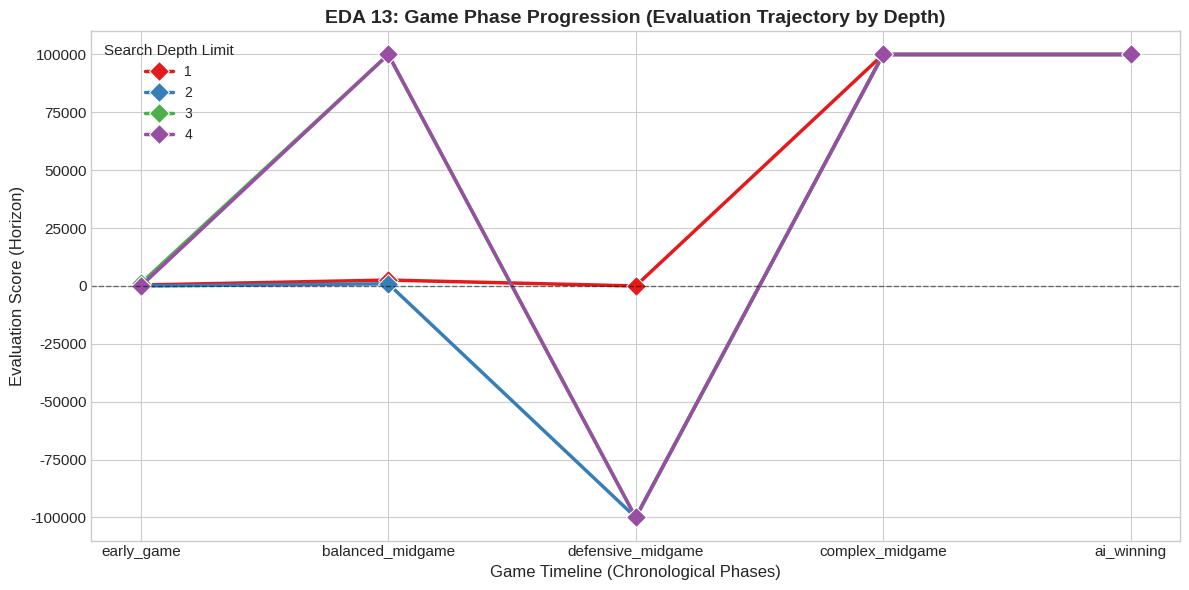

CELL 7 COMPLETED: Saved EDA13_Game_Progression_EN.png


In [7]:
# ==========================================
# CELL 7: EDA 13 - GAME PHASE PROGRESSION
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

# Đọc dữ liệu
df = pd.read_csv('/kaggle/input/datasets/maomaoxiaobng/tmptmp/move_matching.csv')

# Ép kiểu dữ liệu để sắp xếp đúng theo Timeline của 1 ván đấu
phase_order = ['early_game', 'balanced_midgame', 'defensive_midgame', 'complex_midgame', 'ai_winning']
df['Phase_Order'] = pd.Categorical(df['State_Name'], categories=phase_order, ordered=True)
df_sorted = df.sort_values(['Depth_Limit', 'Phase_Order'])

plt.figure(figsize=(12, 6))

# Vẽ biểu đồ Line Chart theo dõi quỹ đạo
sns.lineplot(data=df_sorted, x='State_Name', y='Minimax_Eval_Score', hue='Depth_Limit', 
             marker='D', palette='Set1', linewidth=2.5, markersize=10, errorbar=None)

# Vẽ đường cơ sở 0 điểm
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Tinh chỉnh giao diện
plt.title('EDA 13: Game Phase Progression (Evaluation Trajectory by Depth)', fontsize=14, fontweight='bold')
plt.xlabel('Game Timeline (Chronological Phases)', fontsize=12)
plt.ylabel('Evaluation Score (Horizon)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='Search Depth Limit', title_fontsize='11', fontsize='10', loc='upper left')

plt.tight_layout()
plt.savefig('EDA13_Game_Progression_EN.png', dpi=300, bbox_inches='tight')
plt.show()

print("CELL 7 COMPLETED: Saved EDA13_Game_Progression_EN.png")